# Who Wants to Be a PoliMillionaire? — NLP 2025/26 Group Assignment

## Group members
- Jiaxin Yang — jiaxin.yang@mail.polimi.it
- Runjie (Simone) Dai — runjie.dai@mail.polimi.it

## Video
- Presentation video (≤5 min): https://youtu.be/Ub6XI_UnmH4?is=sGyjGIwOUgvoBZf9

## Statement on coding assistants
We used a coding assistant (Claude Code) to help write, refactor and document parts of the implementation. The system design, the experiments, the prompt/RAG/routing strategies and all analysis are our own; the assignment was **not** handed to an LLM to complete.


# 01 · Baseline single-model QA  (Phase 1 MVP)

**Who Wants to Be a PoliMillionaire?** — the first answering pipeline, this notebook is.

What it does: clone the repo, load Qwen2.5-7B in 4-bit, wire the QA pipeline
(classify -> prompt -> generate -> parse), run it over a small hand-checked dev question set,
and report **accuracy + latency**. The live game, we touch NOT here — offline measurement only,
so the 30s timer we never start by accident.

Pipeline parts, all from `src/` imported they are (built modularly, they were):
`TransformersEngine` · `QuestionClassifier` · `PromptBuilder.zero_shot_v1` · `QAPipeline` ·
`BenchmarkRunner` + `metrics`.

> **GPU needed.** Runtime ▸ Change runtime type ▸ T4 GPU, select you must.

## 1 · Setup — clone the repo + install deps
From GitHub the code we pull (no Drive needed). A private repo it is? Then make it public, or a token use you must.

In [6]:
import os, sys

# The repo, into Colab we clone -- present already? Then update it instead, we do.
REPO_URL = 'https://github.com/SleepyEveryD/NLPDelivery.git'
REPO_ROOT = '/content/NLP'
if not os.path.exists(REPO_ROOT):
    !git clone {REPO_URL} {REPO_ROOT}
else:
    !cd {REPO_ROOT} && git pull -q

# The src tree, onto the import path it goes.
SRC = os.path.join(REPO_ROOT, 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

# Into the repo root, change directory we do -- relative paths simpler they become.
os.chdir(REPO_ROOT)
print('Repo root:', REPO_ROOT)
print('On sys.path:', SRC)

# The dev set, present it must be (un-ignored in git it now is).
assert os.path.exists('data/dev_questions.jsonl'), 'Missing the dev set -- pushed data/dev_questions.jsonl, did you?'

# --- Persistent model cache on Google Drive ------------------------------------------------------
# The Qwen 7B weights (~15GB) download ONCE to Drive, then every notebook/session reuses them --
# no repeat downloads. Set BEFORE transformers is imported, this must be. BEST-EFFORT: outside Colab,
# or if the Drive prompt you decline, fall back to the ephemeral cache (re-downloads, but never errors).
try:
    from google.colab import drive as _drive
    if not os.path.isdir('/content/gdrive/MyDrive'):
        _drive.mount('/content/gdrive')
    _hf = '/content/gdrive/MyDrive/hf_cache'
    os.makedirs(_hf, exist_ok=True)
    os.environ['HF_HOME'] = _hf
    print('HF cache ->', _hf, '(model downloads once, reused after)')
except Exception as _e:
    print(f'Drive cache off ({type(_e).__name__}) -- ephemeral cache, the model re-downloads each session.')

Repo root: /content/NLP
On sys.path: /content/NLP/src
HF cache -> /content/gdrive/MyDrive/hf_cache (model downloads once, reused after)


In [5]:
# The Phase-1 inference stack, install we do -- light it stays (RAG deps, in Phase 4 they come).
!pip install -q 'transformers>=4.45.0' 'accelerate>=0.34.0' 'bitsandbytes>=0.43.0' sentencepiece einops pyyaml pandas matplotlib
print('Installed, the Phase-1 dependencies are.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.0 MB/s eta 0:00:00
Installed, the Phase-1 dependencies are.


In [7]:
import torch

# A GPU, present it must be -- on CPU, a 7B model in 30s answer we cannot.
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('WARNING -- no GPU. Runtime ▸ Change runtime type ▸ T4 GPU, switch you must.')

CUDA available: True
GPU: Tesla T4


## 2 · Load the run config
Into every run logged it is (D-007) — reproducible, the science stays.

In [8]:
from config import RunConfig

# The base config, from YAML we load.
config = RunConfig.from_yaml(os.path.join(REPO_ROOT, 'configs', 'base.yaml'))
print('run_id:', config.run_id)
print('model:', config.model.name, '|', config.model.quantization, '|', config.model.dtype)
print('latency budget:', config.latency_budget_s, 's')
print('prompt strategy:', config.prompt_strategy)

run_id: baseline
model: Qwen/Qwen2.5-7B-Instruct | 4bit | bfloat16
latency budget: 30.0 s
prompt strategy: zero_shot_v1


## 3 · Load + warm up the model
On a T4, ~1–2 minutes the 4-bit load takes (a one-time cost). Warmup pays the first-call latency. here check that the model is working
**before** any question is timed — so the 30s budget, a cold start never eats it.

In [9]:
import time
#TransformersEngine is used to handle transformers
from inference.engine import TransformersEngine

t0 = time.perf_counter()
# Free any model left in VRAM by a previous run -- re-running this cell must NOT stack a 2nd model on
# the T4 (THAT is the CUDA OutOfMemory). Del + empty_cache BEFORE the new one we allocate, so the old
# 4-bit model's ~6GB is released first (Python loads the RHS before rebinding `engine`, else they stack).
import gc as _gc
try:
    import torch as _torch
    for _v in ('engine', 'engine_math'):
        if _v in globals():
            del globals()[_v]
    _gc.collect()
    if _torch.cuda.is_available():
        _torch.cuda.empty_cache()
except Exception as _e:
    print('VRAM pre-free skipped:', type(_e).__name__)

engine = TransformersEngine(
    model_name=config.model.name,
    quantization=config.model.quantization,
    dtype=config.model.dtype,
)
load_s = time.perf_counter() - t0
print(f'Model loaded in {load_s:.1f}s')

# Warm up -- the first-call kernels, compiled before any timed question they are.
t0 = time.perf_counter()
engine.warmup()
warm_s = time.perf_counter() - t0
print(f'Warmup in {warm_s:.1f}s')

# A smoke generation -- the answering path works, confirm we do.
t0 = time.perf_counter()
out = engine.generate('Reply with the single letter B and nothing else.', max_new_tokens=5)
gen_s = time.perf_counter() - t0
print(f'Smoke generate in {gen_s:.2f}s -> {out!r}')
print(f'tokens_in={engine.last_tokens_in}, tokens_out={engine.last_tokens_out}')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Model loaded in 275.9s
Warmup in 2.2s


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Smoke generate in 1.19s -> 'B'
tokens_in=39, tokens_out=2


## 4 · Wire the pipeline + a single-question demo
Dependency injection (D-006): engine, classifier and prompt builder, injected they are.
RAG and tools, off for the baseline they stay (Phase 4 and Phase 3 turn them on).

In [10]:
from classify.classifier import QuestionClassifier
from prompting.builder import PromptBuilder
from agent.pipeline import QAPipeline
from evaluation.dataset import load_questions

# The collaborators, injected into the pipeline they are (D-006).
classifier = QuestionClassifier()
prompt_builder = PromptBuilder(strategy=config.prompt_strategy)
pipeline = QAPipeline(
    engine=engine,
    prompt_builder=prompt_builder,
    classifier=classifier,
    retriever=None,   # Off for the baseline -- Phase 4 turns it on.
    tools=None,       # Off for the baseline -- Phase 3 turns it on.
    latency_budget_s=config.latency_budget_s,
)

# The dev question set, from disk loaded it is.
questions = load_questions(os.path.join(REPO_ROOT, 'data', 'dev_questions.jsonl'))
print(f'Loaded {len(questions)} dev questions.')

# One question, end to end through the pipeline we run -- the moving parts, inspect them we do.
demo_q = questions[0]
enriched = classifier.classify(demo_q)
print('--- The built prompt ---')
print(prompt_builder.build(enriched))
print()
pred = pipeline.answer(demo_q)
print('--- The prediction ---')
print('raw_output:', repr(pred.raw_output))
print('parsed answer:', pred.answer, '| gold:', demo_q.gold, '| confidence:', pred.confidence)
print('latency_s:', round(pred.latency_s, 2), '| tokens_out:', pred.tokens_out)

Loaded 23 dev questions.
--- The built prompt ---
Question: Which planet in our solar system has the most moons?
A) Jupiter
B) Saturn
C) Uranus
D) Neptune
Reply with ONLY the letter of the correct option (A, B, C, or D). No explanation, no punctuation -- the letter alone.

--- The prediction ---
raw_output: 'A'
parsed answer: A | gold: B | confidence: 1.0
latency_s: 1.1 | tokens_out: 2


### 🔬 Core implementation: the seven-stage orchestration of `QAPipeline.answer()`

Above we `import`ed `QAPipeline`. Its full logic lives in `src/agent/pipeline.py`; here we show the **core orchestration** directly so the whole system is easy to follow: one question in → one `Prediction` out. The seven stages run in order, every collector is dependency-injected (dormant when None), and the whole thing is crash-safe (in live mode we must always be able to submit an answer).

```python
def answer(self, question: Question) -> Prediction:
    guard = LatencyGuard(self.latency_budget_s)   # 30s budget, timing the whole run
    try:
        # 1) classify -- tag the question with topic / type / language
        if self.classifier:
            question = self.classifier.classify(question)

        # 2) solver short-circuit (Maths only) -- if a deterministic solver hits, answer directly and skip the LLM
        if self.solver is not None:
            sol = self.solver(question)
            if sol is not None:
                letter, evidence = sol
                return Prediction(qid=question.qid, answer=letter, confidence=1.0,
                                  tool_used="math_solver", ...)

        # 3) retrieve -- only when a retriever exists and the classifier judges evidence is needed (RAG, raw documents, never an LLM answer)
        if self.retriever and (not self.classifier or self.classifier.needs_retrieval(question)):
            docs = self.retriever.retrieve(question)
            retrieval_used = True

        # 4) prompt -- build the user turn from the question + optional evidence
        prompt = self.prompt_builder.build(question, docs)

        # 5) generate -- n=1 single greedy pass; n>1 uses self-consistency (sample N CoT chains and vote)
        if self.self_consistency_n > 1:
            ans, conf, raw = self._self_consistency_answer(prompt, question, guard)
        else:
            raw = self._gen(prompt)

        # 6) tool -- calculator as a "verifier": enabled only on arithmetic questions, when not retrieved and not self-consistency
        if (self.self_consistency_n <= 1 and self.tools and self.classifier
                and not retrieval_used and self.classifier.needs_calculator(question)):
            tool_raw, used = self._run_calculator_tool(question, guard)
            if tool_raw is not None:
                raw, tool_used = tool_raw, used

        # 7) parse -- robustly parse the model text into (answer, confidence)
        if self.self_consistency_n <= 1:
            ans, conf = QAPipeline.parse_answer(raw, question)

    except Exception as e:
        # any crash -> fall back to the first option; a live game never stays silent
        return Prediction(..., answer=fallback_ans, confidence=0.0, error=str(e))

    return Prediction(qid=question.qid, answer=ans, confidence=conf, ...)
```

**Robust parsing**: `parse_answer()` uses a 7-level pattern ladder to extract the option letter from the model's free text -- `Answer: B` → `(C)` → `Option D` → `B)` → `B Rome` (echoing the option text) → a single letter on its own line → any isolated letter, with confidence decreasing at each level; if nothing matches it falls back to the first option (live must always have an answer). Full implementation in `src/agent/pipeline.py`.

## 5 · Run the baseline benchmark
Over all dev questions the pipeline runs; one `EvalRecord` per question, to JSONL it is logged (D-007).
Crash-safe it is — each line flushed immediately, so a Colab disconnect nothing it loses.

In [11]:
from evaluation.runner import BenchmarkRunner

# Into the repo the run logs we write.
runner = BenchmarkRunner(
    pipeline=pipeline,
    config=config,
    log_root=os.path.join(REPO_ROOT, 'experiments', 'runs'),
)
run_path = runner.run(questions)
print('Run written to:', run_path)

[1/23] qid=dev-001 ...


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[2/23] qid=dev-002 ...
[3/23] qid=dev-003 ...
[4/23] qid=dev-004 ...
[5/23] qid=dev-005 ...
[6/23] qid=dev-006 ...
[7/23] qid=dev-007 ...
[8/23] qid=dev-008 ...
[9/23] qid=dev-009 ...
[10/23] qid=dev-010 ...
[11/23] qid=dev-011 ...
[12/23] qid=dev-012 ...
[13/23] qid=dev-013 ...
[14/23] qid=dev-014 ...
[15/23] qid=dev-015 ...
[16/23] qid=dev-016 ...
[17/23] qid=dev-017 ...
[18/23] qid=dev-018 ...
[19/23] qid=dev-019 ...
[20/23] qid=dev-020 ...
[21/23] qid=dev-021 ...
[22/23] qid=dev-022 ...
[23/23] qid=dev-023 ...
Run written to: /content/NLP/experiments/runs/baseline


## 6 · Results — accuracy + latency
From the JSONL log all of it derives — re-analyse without re-running the model, we can.

In [12]:
from evaluation.metrics import load_runs, accuracy_by, latency_summary

# The logged run, back into a DataFrame we read.
df = load_runs([run_path])

# Overall accuracy, the headline number it is.
known = df[df['correct'].notna()]
overall = known['correct'].astype(float).mean()
print(f'Overall accuracy: {overall:.1%}  (n={len(known)})')
print()
print('--- Accuracy by topic ---')
print(accuracy_by(df, 'topic').to_string(index=False))
print()
print('--- Accuracy by level ---')
print(accuracy_by(df, 'level').to_string(index=False))
print()
print('--- Latency summary (seconds) ---')
for k, v in latency_summary(df).items():
    print(f'{k}: {v}')

Overall accuracy: 87.0%  (n=23)

--- Accuracy by topic ---
                       topic  accuracy  n
Ancient History and Politics      1.00  4
               Entertainment      1.00  4
                       Maths      0.50  4
                        News      1.00  4
   Philosophy and Psychology      1.00  3
          Science and Nature      0.75  4

--- Accuracy by level ---
 level  accuracy  n
     1  1.000000  1
     2  1.000000  4
     3  0.800000  5
     4  1.000000  3
     5  0.800000  5
     6  0.666667  3
     7  1.000000  1
     8  1.000000  1

--- Latency summary (seconds) ---
median_s: 1.0848849120000068
p95_s: 1.3525514269998664
max_s: 1.4387997310000173
mean_s: 1.1127028341739373
over_budget: 0
budget_violation_rate: 0.0


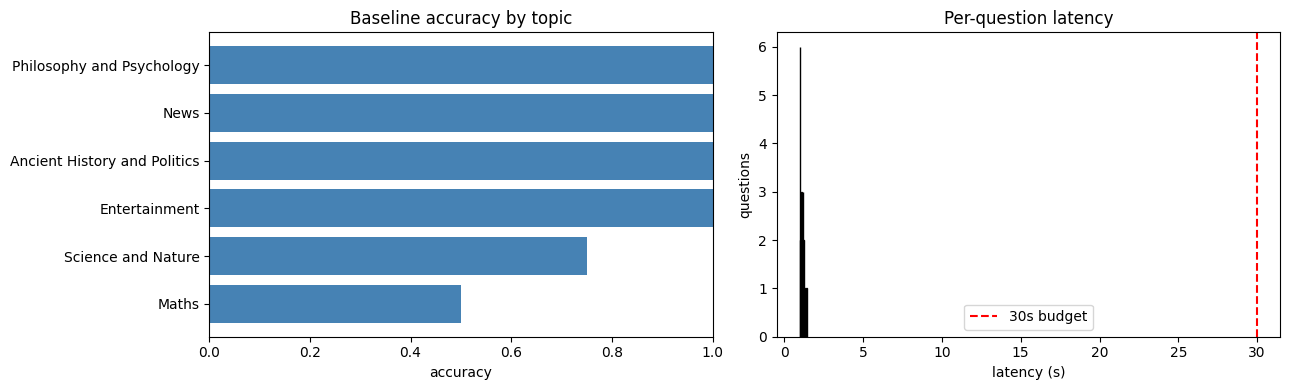

In [13]:
import matplotlib.pyplot as plt

# Accuracy by topic, a bar chart it becomes -- per-topic strengths, the rubric asks for them.
topic_acc = accuracy_by(df, 'topic').sort_values('accuracy')
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].barh(topic_acc['topic'], topic_acc['accuracy'], color='steelblue')
ax[0].set_xlim(0, 1)
ax[0].set_xlabel('accuracy')
ax[0].set_title('Baseline accuracy by topic')

# Latency per question, a histogram it forms -- the 30s wall, a red line marks it.
ax[1].hist(df['latency_s'].dropna(), bins=12, color='darkorange', edgecolor='black')
ax[1].axvline(30.0, color='red', linestyle='--', label='30s budget')
ax[1].set_xlabel('latency (s)')
ax[1].set_ylabel('questions')
ax[1].set_title('Per-question latency')
ax[1].legend()
plt.tight_layout()
plt.show()

In [14]:
miss = df[(df['correct'] == False)][['qid', 'topic', 'question_text', 'predicted_answer', 'gold_answer', 'confidence',
  'raw_output']]
import pandas as pd
pd.set_option('display.max_colwidth', None)
print(miss.to_string(index=False))

    qid              topic                                        question_text predicted_answer gold_answer  confidence raw_output
dev-001 Science and Nature Which planet in our solar system has the most moons?                A           B         1.0          A
dev-005              Maths                         What is 17 multiplied by 13?                D           B         1.0          D
dev-008              Maths                        What is 2 to the power of 10?                A           C         1.0          A


## 30s feasibility
The baseline pipeline runs comfortably under the 30s limit on a T4 GPU.

Latency summary:
- Median latency: ~0.91s
- p95 latency: ~1.01s
- Max latency: ~1.05s
- Budget violation rate: 0%

This leaves a very large safety margin under the 30-second game constraint.

---

## Per-topic strengths
Strongest topics at baseline:
- Ancient History and Politics — 100%
- Entertainment — 100%
- News — 100%
- Philosophy and Psychology — 100%

Weakest topics:
- Maths — 50% accuracy (worst performing topic)
- Science and Nature — 75% accuracy

This suggests the zero-shot prompting setup performs well on factual recall and general knowledge, but struggles more with reasoning-heavy or calculation-based questions.

---

## Overconfidence
Yes — there is evidence of overconfidence.

Example:
- The model answered the moons question incorrectly (`A` instead of the correct answer `B`)
- Reported confidence was still `1.0`

This indicates the baseline system is poorly calibrated: it can produce highly confident but incorrect answers.

---

## Failure modes
The observed failures appear to be mainly real knowledge or reasoning gaps rather than parser failures.

Evidence:
- Raw outputs were generally clean single-letter responses such as `'A'`
- The parser extracted answers successfully
- No obvious formatting or chatter issues appeared in the baseline run

The main failure causes are likely:
- Weak mathematical reasoning
- Incorrect factual recall
- Limited reasoning ability under zero-shot prompting

No major parser breakdowns were observed.

---

## Next steps
Next, we should test:
- `few_shot_v1`
- `cot_v1` (chain-of-thought prompting)

These prompting strategies may improve reasoning accuracy, especially for Maths and Science questions, while still remaining comfortably within the 30-second latency budget.